- Random Forest

In [56]:
import sys
!{sys.executable} -m pip install scikit-learn joblib pandas numpy matplotlib --quiet

In [57]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

| ---------- Import File ---------- |

In [58]:
df = pd.read_csv('../data/dataset_building.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (60, 6)


,Building_ID,Age_Years,Crack_Length_mm,Crack_Width_mm,Material,Severity_Level
0,B001,12.0,15.5,2.1,Concrete,Low
1,B002,NaN,45.0,5.3,Brick,High
2,B003,5.0,"Unknown""""""",0.5,Concrete,Low
3,B004,30.0,120.0,999,NaN,Critical
4,B005,22.0,30.2,3.1,"""Con-crete""",Medium


| ---------- Clean Data ---------- |

In [59]:
df_clean = df.copy()

# --- Fix Material (dirty strings) ---
def clean_material(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().strip('"').replace('-', '').replace(' ', '').lower()
    mapping = {
        'concrete': 'Concrete',
        'brick':    'Brick',
        'steel':    'Steel',
        'wood':     'Wood',
        'glass':    'Glass',
    }
    return mapping.get(val, np.nan)

df_clean['Material'] = df_clean['Material'].apply(clean_material)

# --- Fix Crack_Length_mm (string -> float) ---
def clean_crack_length(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip().replace('"', '')
    if 'unknown' in val_str.lower() or not val_str.replace('.', '', 1).isdigit():
        return np.nan
    return float(val_str)

df_clean['Crack_Length_mm'] = df_clean['Crack_Length_mm'].apply(clean_crack_length)

# --- Fix Crack_Width_mm (non-numeric strings) ---
df_clean['Crack_Width_mm'] = pd.to_numeric(df_clean['Crack_Width_mm'], errors='coerce')

# --- Remove impossible Age_Years ---
df_clean.loc[df_clean['Age_Years'] < 0,   'Age_Years'] = np.nan
df_clean.loc[df_clean['Age_Years'] > 200, 'Age_Years'] = np.nan

# --- Cap extreme Crack_Length_mm outliers ---
df_clean.loc[df_clean['Crack_Length_mm'] > 1000, 'Crack_Length_mm'] = np.nan

# --- Remove impossible Crack_Width_mm ---
df_clean.loc[df_clean['Crack_Width_mm'] < 0,   'Crack_Width_mm'] = np.nan
df_clean.loc[df_clean['Crack_Width_mm'] > 100, 'Crack_Width_mm'] = np.nan

# --- Drop rare/unknown target label ---
valid_labels = ['Low', 'Medium', 'High', 'Critical']
df_clean = df_clean[df_clean['Severity_Level'].isin(valid_labels)]

# --- Fill numeric NaN with median ---
for col in ['Age_Years', 'Crack_Length_mm', 'Crack_Width_mm']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- Fill Material NaN with mode ---
df_clean['Material'] = df_clean['Material'].fillna(df_clean['Material'].mode()[0])

print(f'Shape after cleansing: {df_clean.shape}')
print('Null counts:')
print(df_clean.isnull().sum())
df_clean.head()

Shape after cleansing: (59, 6)
Null counts:
Building_ID        0
Age_Years          0
Crack_Length_mm    0
Crack_Width_mm     0
Material           0
Severity_Level     0
dtype: int64


,Building_ID,Age_Years,Crack_Length_mm,Crack_Width_mm,Material,Severity_Level
0,B001,12.0,15.50,2.1,Concrete,Low
1,B002,19.0,45.00,5.3,Brick,High
2,B003,5.0,28.85,0.5,Concrete,Low
3,B004,30.0,120.00,3.0,Concrete,Critical
4,B005,22.0,30.20,3.1,Concrete,Medium


In [60]:
le_material = LabelEncoder()
df_clean['Material_enc'] = le_material.fit_transform(df_clean['Material'])

le_target = LabelEncoder()
df_clean['Target'] = le_target.fit_transform(df_clean['Severity_Level'])

print('Material encoding:', dict(zip(le_material.classes_, le_material.transform(le_material.classes_))))
print('Target encoding:  ', dict(zip(le_target.classes_,  le_target.transform(le_target.classes_))))

feature_cols = ['Age_Years', 'Crack_Length_mm', 'Crack_Width_mm', 'Material_enc']
X = df_clean[feature_cols]
y = df_clean['Target']

print(f'\nClass distribution:\n{df_clean["Severity_Level"].value_counts()}')

Material encoding: {'Brick': np.int64(0), 'Concrete': np.int64(1), 'Glass': np.int64(2), 'Steel': np.int64(3), 'Wood': np.int64(4)}
Target encoding:   {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}

Class distribution:
Severity_Level
Low         23
Medium      13
High        12
Critical    11
Name: count, dtype: int64


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 47 rows | Test: 12 rows


In [62]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
print('Training complete!')

Training complete!


In [63]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=le_target.classes_, columns=le_target.classes_))

Accuracy: 0.8333 (83.33%)

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00         2
        High       1.00      1.00      1.00         2
         Low       0.80      0.80      0.80         5
      Medium       0.67      0.67      0.67         3

    accuracy                           0.83        12
   macro avg       0.87      0.87      0.87        12
weighted avg       0.83      0.83      0.83        12

Confusion Matrix:
          Critical  High  Low  Medium
Critical         2     0    0       0
High             0     2    0       0
Low              0     0    4       1
Medium           0     0    1       2


Feature Importances:


<Axes: title={'center': 'Feature Importances'}>

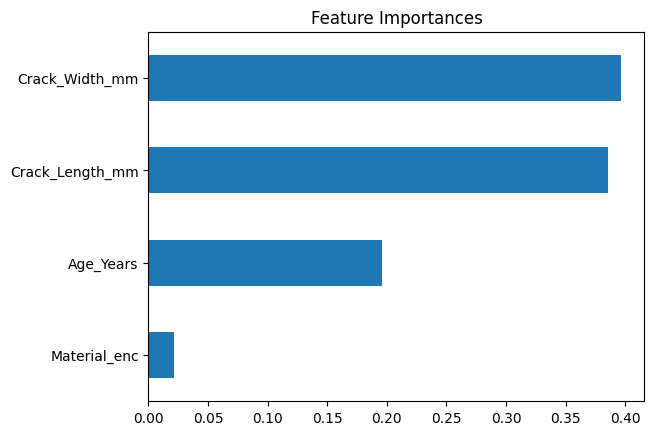

In [64]:
print('Feature Importances:')
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).plot(kind='barh', title='Feature Importances')

In [65]:
os.makedirs('models', exist_ok=True)

joblib.dump(rf_model,    '../models/random_forest_model.pkl')
joblib.dump(le_material, '../models/le_material.pkl')
joblib.dump(le_target,   '../models/le_target.pkl')
df_clean.to_csv('../data/dataset_building_cleaned.csv', index=False)

print('Saved:')
print('  models/random_forest_model.pkl')
print('  models/le_material.pkl')
print('  models/le_target.pkl')
print('  data/dataset_building_cleaned.csv')
print('\nDone!')

Saved:
  models/random_forest_model.pkl
  models/le_material.pkl
  models/le_target.pkl
  data/dataset_building_cleaned.csv

Done!


- KNN

In [66]:
import sys
!{sys.executable} -m pip install scikit-learn joblib pandas numpy matplotlib --quiet

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [68]:
df = pd.read_csv('../data/dataset_building_cleaned.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (59, 8)


,Building_ID,Age_Years,Crack_Length_mm,Crack_Width_mm,Material,Severity_Level,Material_enc,Target
0,B001,12.0,15.50,2.1,Concrete,Low,1,2
1,B002,19.0,45.00,5.3,Brick,High,0,1
2,B003,5.0,28.85,0.5,Concrete,Low,1,2
3,B004,30.0,120.00,3.0,Concrete,Critical,1,0
4,B005,22.0,30.20,3.1,Concrete,Medium,1,3


In [69]:
le_material = LabelEncoder()
df['Material_enc'] = le_material.fit_transform(df['Material'])

le_target = LabelEncoder()
df['Target'] = le_target.fit_transform(df['Severity_Level'])

print('Material encoding:', dict(zip(le_material.classes_, le_material.transform(le_material.classes_))))
print('Target encoding:  ', dict(zip(le_target.classes_,  le_target.transform(le_target.classes_))))

feature_cols = ['Age_Years', 'Crack_Length_mm', 'Crack_Width_mm', 'Material_enc']
X = df[feature_cols]
y = df['Target']

print(f'\nClass distribution:\n{df["Severity_Level"].value_counts()}')

Material encoding: {'Brick': np.int64(0), 'Concrete': np.int64(1), 'Glass': np.int64(2), 'Steel': np.int64(3), 'Wood': np.int64(4)}
Target encoding:   {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}

Class distribution:
Severity_Level
Low         23
Medium      13
High        12
Critical    11
Name: count, dtype: int64


In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (first row):', X.iloc[0].values)
print('After  scaling (first row):', X_scaled[0].round(4))

Before scaling (first row): [12.  15.5  2.1  1. ]
After  scaling (first row): [-0.8712 -0.6328 -0.432  -0.0685]


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 47 rows | Test: 12 rows


Best K = 1  (CV Accuracy = 0.7822)


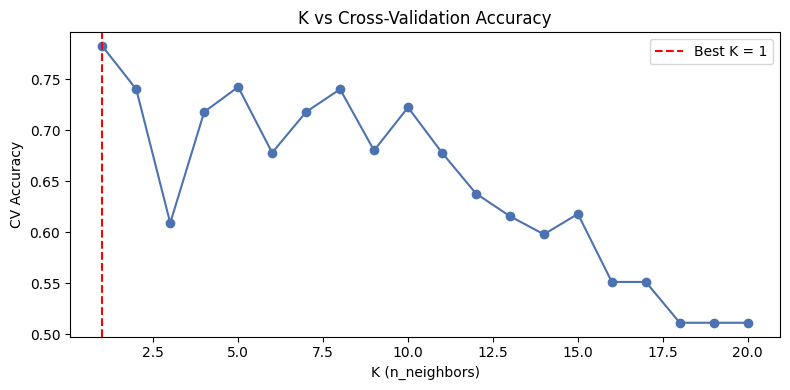

In [72]:
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score แบ่ง train set เป็น 5 fold แล้วหาค่าเฉลี่ย
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f'Best K = {best_k}  (CV Accuracy = {max(cv_scores):.4f})')

# Plot K vs Accuracy
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, cv_scores, marker='o', color='#4C72B0')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('K (n_neighbors)')
ax.set_ylabel('CV Accuracy')
ax.set_title('K vs Cross-Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',   # วัดระยะห่างแบบ Euclidean (เส้นตรง)
    weights='uniform'     # ทุก neighbor มีน้ำหนักเท่ากัน
)
knn_model.fit(X_train, y_train)
print(f'Training complete! (K = {best_k})')

Training complete! (K = 1)


In [74]:
y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=le_target.classes_, columns=le_target.classes_))

Accuracy: 0.7500 (75.00%)

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00         2
        High       0.67      1.00      0.80         2
         Low       1.00      0.60      0.75         5
      Medium       0.50      0.67      0.57         3

    accuracy                           0.75        12
   macro avg       0.79      0.82      0.78        12
weighted avg       0.82      0.75      0.76        12

Confusion Matrix:
          Critical  High  Low  Medium
Critical         2     0    0       0
High             0     2    0       0
Low              0     0    3       2
Medium           0     1    0       2


        Model Accuracy
Random Forest   83.33%
    KNN (K=1)   75.00%


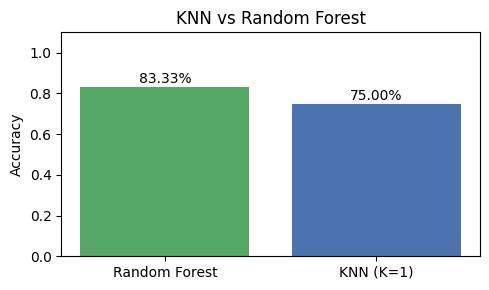

In [75]:
# โหลด RF model มาเปรียบเทียบ
rf_model = joblib.load('../models/random_forest_model.pkl')

X_train_raw, X_test_raw, _, _ = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf_pred = rf_model.predict(X_test_raw)
rf_acc  = accuracy_score(y_test, rf_pred)
knn_acc = accuracy_score(y_test, y_pred)

compare_df = pd.DataFrame({
    'Model':    ['Random Forest', f'KNN (K={best_k})'],
    'Accuracy': [f'{rf_acc*100:.2f}%', f'{knn_acc*100:.2f}%']
})
print(compare_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(compare_df['Model'], [rf_acc, knn_acc], color=['#55A868', '#4C72B0'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('KNN vs Random Forest')
for bar, val in zip(bars, [rf_acc, knn_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [76]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(knn_model,   '../models/knn_model.pkl')
joblib.dump(scaler,      '../models/knn_scaler.pkl')   
joblib.dump(le_material, '../models/le_material.pkl')
joblib.dump(le_target,   '../models/le_target.pkl')

print('Saved:')
print('  models/knn_model.pkl')
print('  models/knn_scaler.pkl   ← สำคัญ! ต้องใช้ scale input ก่อน predict')
print('  models/le_material.pkl')
print('  models/le_target.pkl')
print('\nDone!')

Saved:
  models/knn_model.pkl
  models/knn_scaler.pkl   ← สำคัญ! ต้องใช้ scale input ก่อน predict
  models/le_material.pkl
  models/le_target.pkl

Done!


- Support Vector Machines

In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn joblib pandas numpy matplotlib --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv('../data/dataset_building_cleaned.csv')
print(f'Shape: {df.shape}')
df.head()

In [ ]:
le_material = LabelEncoder()
df['Material_enc'] = le_material.fit_transform(df['Material'])

le_target = LabelEncoder()
df['Target'] = le_target.fit_transform(df['Severity_Level'])

print('Material encoding:', dict(zip(le_material.classes_, le_material.transform(le_material.classes_))))
print('Target encoding:  ', dict(zip(le_target.classes_,  le_target.transform(le_target.classes_))))

feature_cols = ['Age_Years', 'Crack_Length_mm', 'Crack_Width_mm', 'Material_enc']
X = df[feature_cols]
y = df['Target']

print(f'\nClass distribution:\n{df["Severity_Level"].value_counts()}')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (first row):', X.iloc[0].values)
print('After  scaling (first row):', X_scaled[0].round(4))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

In [ ]:
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma':  ['scale', 'auto']   
}

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)
grid_search.fit(X_train, y_train)

print('Best Params: ', grid_search.best_params_)
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

In [ ]:
svm_model = grid_search.best_estimator_
print(f'SVM trained with: {grid_search.best_params_}')

In [ ]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=le_target.classes_, columns=le_target.classes_))

In [ ]:
# โหลด RF และ KNN มาเปรียบเทียบ
rf_model  = joblib.load('models/random_forest_model.pkl')
knn_model = joblib.load('models/knn_model.pkl')
knn_scaler = joblib.load('models/knn_scaler.pkl')

# RF ใช้ X ไม่ scale
X_train_raw, X_test_raw, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_pred  = rf_model.predict(X_test_raw)
rf_acc   = accuracy_score(y_test, rf_pred)

# KNN ใช้ scaler ของตัวเอง
knn_pred = knn_model.predict(knn_scaler.transform(X_test_raw))
knn_acc  = accuracy_score(y_test, knn_pred)

svm_acc  = accuracy_score(y_test, y_pred)

# แสดงตาราง
compare_df = pd.DataFrame({
    'Model':    ['Random Forest', f'KNN (K={knn_model.n_neighbors})', f'SVM ({grid_search.best_params_["kernel"]})'],
    'Accuracy': [rf_acc, knn_acc, svm_acc]
})
compare_df['Accuracy (%)'] = (compare_df['Accuracy'] * 100).round(2)
print(compare_df[['Model', 'Accuracy (%)']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#55A868', '#4C72B0', '#C44E52']
bars = ax.bar(compare_df['Model'], compare_df['Accuracy'], color=colors)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: RF vs KNN vs SVM')
for bar, val in zip(bars, compare_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('models', exist_ok=True)

joblib.dump(svm_model,   '../models/svm_model.pkl')
joblib.dump(scaler,      '../models/svm_scaler.pkl')  
joblib.dump(le_material, '../models/le_material.pkl')
joblib.dump(le_target,   '../models/le_target.pkl')

print('Saved:')
print('  models/svm_model.pkl')
print('  models/svm_scaler.pkl   ← ต้องใช้ scale input ก่อน predict')
print('  models/le_material.pkl')
print('  models/le_target.pkl')
print('\nDone!')